# imports

In [1]:
import matplotlib.pyplot as plt 
from glob import glob 

# read in timing log

In [ ]:
def grab_time_eamxx(casedir): 
    lines_to_read = range(34, 40) 
    sypdlog = glob(f'{casedir}/timing/e3sm_timing.*')[-1]  
    with open(sypdlog) as f:
        all_lines = f.readlines()
    result = [all_lines[i-1].rstrip() for i in lines_to_read]
    sypd = result[1].split()[2]
    return float(sypd) 

    
def grab_time_eam(casedir):
    lines_to_read = range(33, 39)
    sypdlog = glob(f'{casedir}/timing/e3sm_timing.*')[-1]  
    with open(sypdlog) as f:
        all_lines = f.readlines()
    result = [all_lines[i-1].rstrip() for i in lines_to_read]
    sypd = result[1].split()[2]
    return float(sypd) 

# plot

128: 0.57 sypd
144: 0.62 sypd
160: 0.7 sypd


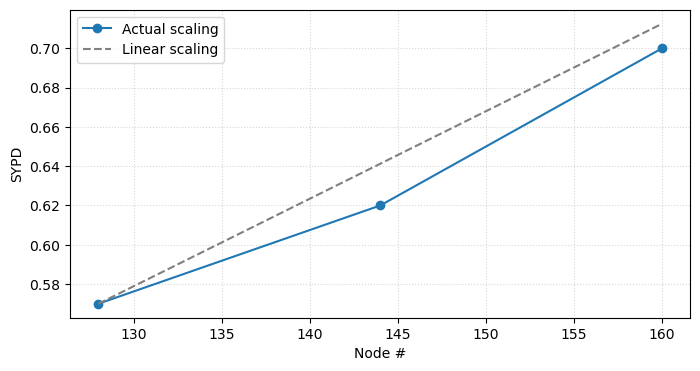

In [ ]:
casedir = '/path/to/cases'  # MODIFY THIS PATH
sims = {
    # node #: 'path/to/case', 
    1: f'{casedir}/sim1',
    2: f'{casedir}/sim2',
    3: f'{casedir}/sim3',
}  

is_eamxx = True  

sypd = []
for case in sims:
    indir = sims[case]
    if is_eamxx:
        time = grab_time_eamxx(indir)
    else:
        time = grab_time_eam(indir)
    print(f'{case}: {time} sypd')
    sypd.append(time)
    
k = sypd[0] / next(iter(sims.keys())) 
linear = [k * n for n in sims.keys()] 
    
# Plotting
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(list(sims.keys()), sypd, marker='o', label='Actual scaling')
ax.plot(list(sims.keys()), linear, linestyle='--', color='gray', label='Linear scaling')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlabel('Node #')
ax.set_ylabel('SYPD')
ax.legend()